In [3]:
from Utils import Utils
import numpy as np
import matplotlib.pyplot as plt
#from qiskit import QuantumCircuit,ClassicalRegister,QuantumRegister, transpile
#from qiskit_aer import AerSimulator
#from qiskit.visualization import plot_histogram

<h1 style="color:blue;">The Grover-Rudolph Algorithm</h1>

<h3 style="color:green;">Theorem (Rudolph-Grover)</h3>

Let $(\mathsf{A}, \rho_0, \mathcal{N})$ be an universal digital quantum computer in $\mathcal{A}_{2^n}.$ Given $\varrho: [0,1] \subset \mathbb{R} \rightarrow  [0,\infty)$, a non-negative function satisfying 
$$
\int_0^1 \varrho(x) \, dx = 1,
$$
there exists a quantum circuit $\mathsf{U} := \mathsf{U}_{\ell} \mathsf{U}_{\ell-1} \cdots \mathsf{U}_1$ of length $\ell = 2^n-1$ such that the law of the output quantum random variable $(\mathsf{A}, \mathcal{N}_{\rho_0}(\mathsf{U}))$ satisfies
$$
\mathbb{P}_{\mathcal{N}_{\rho_0}(\mathsf{U})}(\mathsf{A} = k) = \int_{\frac{k}{2^n}}^{\frac{k+1}{2^n}} \varrho(x) \, dx \quad \text{for each } k \in \mathbb{Z}_{2^n}.
$$



<span style="color:red; font-size:18px;">Example 1:

Given the following density function:

$$
\rho(x) = \begin{cases}
4x & \text{if } 0 \leq x \leq \frac{1}{2}, \\
4 - 4x & \text{if } \frac{1}{2} \leq x \leq 1.
\end{cases}
$$

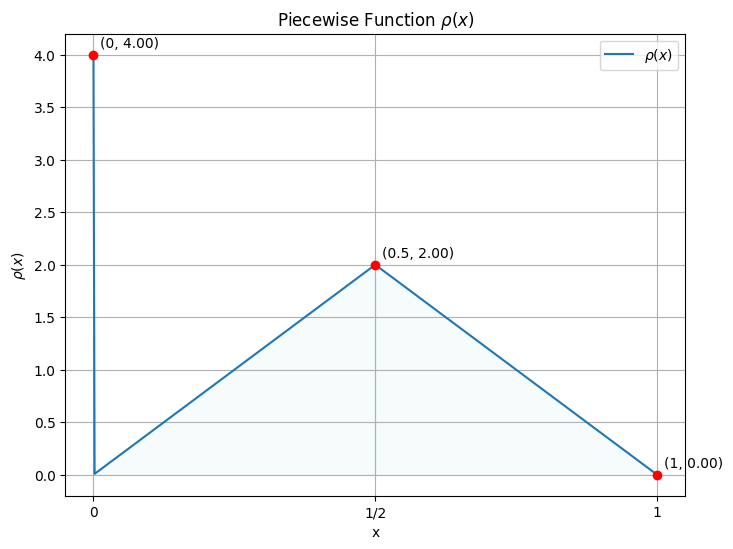

In [8]:

# Generate x values for plotting
x_values = np.linspace(0, 1, 500)  # Adjust number of points for smoother plot

# Plot the function
plt.figure(figsize=(8, 6))

# Plot the function without shading
plt.plot(x_values, Utils.f(x_values), label=r'$\rho(x)$')

# Shade the area inside the triangle
plt.fill_between(x_values, 0, Utils.f(x_values), where=(x_values >= 0) & (x_values <= 0.5), color='lightblue', alpha=0.1)
plt.fill_between(x_values, 0, Utils.f(x_values), where=(x_values > 0.5) & (x_values <= 1), color='lightblue', alpha=0.1)

# Plot points at selected nodes
nodes = [0, 0.5, 1]
for node in nodes:
    plt.scatter(node, Utils.f(np.array([node])), color='red', zorder=5)  # zorder ensures points are plotted above the filled area

    # Annotate the point with its coordinates
    plt.annotate(f'({node}, {Utils.f(np.array([node]))[0]:.2f})', (node, Utils.f(np.array([node]))[0]), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel('x')
plt.ylabel(r'$\rho(x)$')
plt.title('Piecewise Function $\\rho(x)$')
plt.grid(True)

# Set x-axis ticks to show 0, 1/2, and 1
plt.xticks([0, 0.5, 1], ['0', '1/2', '1'])

plt.legend()
plt.show()
